In [1]:
import numpy as np
import pickle as pkl

import concurrent.futures
import pickle as pkl
import time
from one.api import ONE
import pandas as pd
from tqdm import tqdm
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ibl_info.utils import check_config, compute_animal_stats, get_trial_masks_detailed
from scipy.ndimage import convolve1d
import traceback
from scipy.stats import zscore
import pickle as pkl
import numpy as np
import random

import pickle as pkl
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainwidemap import bwm_query, bwm_units, load_good_units, load_trials_and_mask
from tqdm import tqdm
from one.api import ONE
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ibl_info.utils import check_config
from ibl_info.rsa_regression import (
    ideal_rsa_matrices,
    run_rsa_regression,
    simpler_rsa_matrices,
    run_rsa_regression_with_reward,
)
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
from ibl_info.manifold import (
    plot_pcas_separate_decomposition,
    plot_pcas_separate_decomposition_adapted,
)
import warnings
from ibl_info.rsa_regression import plot_rsa_dynamics

warnings.filterwarnings("ignore")

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# load the data
# organize the rsa matrices properly

In [4]:
with open(
    "../data/processed/all_eids_dict_for_preceding_reward_history_older_conditions.pkl", "rb"
) as f:
    rsa_reward = pkl.load(f)

In [5]:
with open("../data/generated/manifold/old_manifolds/bwm_manifold_8conditions.pkl", "rb") as f:
    manifold = pkl.load(f)

In [6]:
config = check_config()
MY_REGIONS = config["stim_prior_regions"]
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    password="international",
    silent=True,
    username="intbrainlab",
)
print("Querying BWM Units...")

units_df = bwm_units(one)
relevant_pids = units_df[units_df["Beryl"].isin(MY_REGIONS)]["pid"].unique()

bwm_df = bwm_query(one)
subset_df = bwm_df[bwm_df["pid"].isin(relevant_pids)]

eid_region_mapping = {}
for region in manifold.keys():
    pid_region = units_df[units_df["Beryl"] == region]["pid"].unique()
    eid_region = bwm_df[bwm_df["pid"].isin(pid_region)]["eid"].unique()
    eid_region_mapping[region] = eid_region

Querying BWM Units...
Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01
Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [47]:
condition_keys = [
    "L_Cong_Corr",
    "L_Cong_Err",
    "L_Incong_Corr",
    "L_Incong_Err",
    "R_Cong_Corr",
    "R_Cong_Err",
    "R_Incong_Corr",
    "R_Incong_Err",
]

In [48]:
model_vectors, model_names, model_matrices = ideal_rsa_matrices()

In [49]:
model_names

['Choice', 'Prior', 'Congruence', 'Stimulus']

In [50]:
model_names

['Choice', 'Prior', 'Congruence', 'Stimulus']

In [77]:
q = run_rsa_regression_with_reward(
    manifold,
    model_vectors=model_vectors,
    model_names=model_names,
    conditions=8,
    reward_dict=rsa_reward,
    condition_keys=condition_keys,
    normalization=False,
    model_type="NNLS",
)

Processing VISp...
Processing MOs...
Processing SSp-ul...
Processing ACAd...
Processing PL...
Processing CP...
Processing VPM...
Processing MG...
Processing LGd...
Processing ZI...
Processing SNr...
Processing MRN...
Processing SCm...
Processing PAG...
Processing APN...
Processing RN...
Processing PPN...
Processing PRNc...
Processing PRNr...
Processing GRN...
Processing IRN...
Processing PGRN...
Processing CUL4 5...
Processing SIM...
Processing IP...


In [79]:
# for rx in manifold.keys():
#     plot_rsa_dynamics(
#         q, rx, model_names=["Choice", "Prior", "Congruence", "Stimulus", "Previous Outcome"]
#     )

In [ ]:
from ibl_info.rsa_regression import plot_rsa_summary_bars


epoch_data = plot_rsa_summary_bars(
    q, model_names=["Choice", "Prior", "Congruence", "Stimulus", "Previous Outcome"]
)

<Axes: xlabel='Region', ylabel='Beta'>

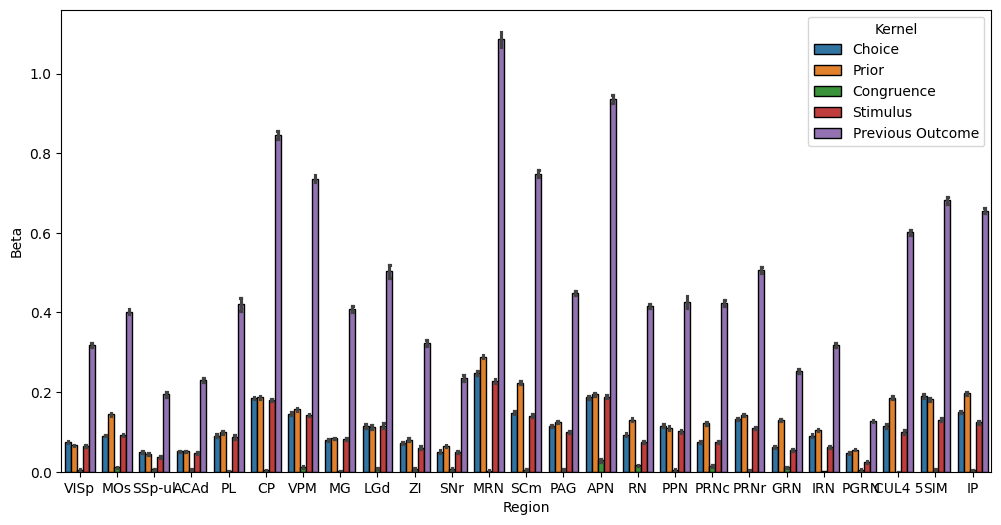

In [91]:
epoch_data_x = epoch_data[epoch_data["Epoch"] == "Quiescent"]


fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=epoch_data_x,
    x="Region",
    y="Beta",
    hue="Kernel",
    edgecolor="black",
    errorbar="se",  # Calculates SEM
    capsize=0.1,  # Adds little caps to the error bars
)

In [87]:
epoch_data["Epoch"].unique()

array(['Choice'], dtype=object)